YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


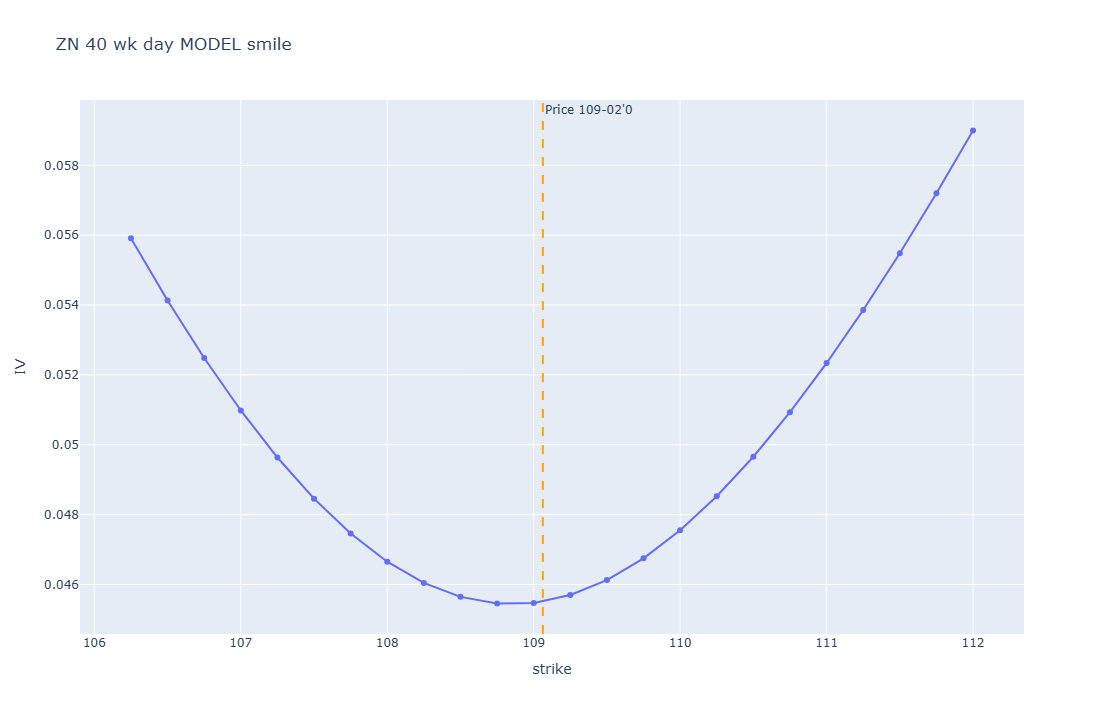

In [1]:
import yfinance as yf
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import requests
import math
from math import erf, exp, log, sqrt
from scipy import stats
from scipy.stats import norm
import sys
sys.path.append('..')
from utils.black76 import *
from utils.my_models import *

smile_symbol = 'ZN=F'
fig_hv22_10, hv_df_10_fig, cur_hv_10, cur_fut_10, df_yahoo_10, cur_iv_10, merged_df_10, hv_df_10 = hv_iv_fig(symbol=smile_symbol, move_mult=16)

df_for_smile = df_yahoo_10
df_for_smile['change'] = df_for_smile['Close'][smile_symbol].pct_change(periods=40)
df_for_smile = df_for_smile.dropna()

mu, sigma = df_for_smile["change"].mean(), df_for_smile["change"].std()
x_0 = np.linspace(df_for_smile["change"].min(), df_for_smile["change"].max(), 500)
x_log = np.log1p(x_0)

normal_pdf = stats.norm.pdf(x_log, mu, sigma)
kde = stats.gaussian_kde(x_log)
kde_pdf = kde(x_log)

dist_df = pd.DataFrame({
    "x": x_log,
    "normal_pdf": normal_pdf,
    "kde_pdf": kde_pdf
})

F = cur_fut_10
hv_atm = cur_hv_10

L = abs(dist_df['x'].iloc[0])
R = abs(dist_df['x'].iloc[-1])
peak_shift_log = dist_df[dist_df['normal_pdf'] == dist_df['normal_pdf'].max()]['x'].iloc[0]

hints = suggest_svi_tuning(L, R, peak_shift_log=peak_shift_log)

PRICE_RANGE_PCT = cur_iv_10 * np.sqrt(40/252) / 100 * 1.5
strike_low = 1 - PRICE_RANGE_PCT
strike_high = 1 + PRICE_RANGE_PCT

price_to_chart = float_to_cme_price(F)

smile_df = make_smile_df(
    F, hv_atm, 40,
    preset="commodities",
    skew_strength=hints["skew_strength"],
    center_shift=hints["center_shift"],
    sigma_scale=hints["sigma_scale"],
    strike_low=strike_low, strike_high=strike_high,
    strike_step=0.25,
    rho_override=hints["rho_hint"],
    align_min_to_center=True
)

smile_fig = px.line(
    smile_df,
    x='strike',
    y='IV',
    width=1500,
    height=700,
    title=f'{smile_symbol[:2]} 40 wk day MODEL smile',
    markers=True
)
smile_fig.add_vline(
    x=F,
    line_width=2,
    line_dash="dash",
    line_color="orange",
    annotation_text=f"Price {price_to_chart}",
    annotation_position="top right"
)
smile_fig.show()
smile_fig.write_html('../charts/model_smile.html')
